# Analysis of Household Energy Consumption and Socio-Economic Equity in Germany

**Author: Maximilian Starp**

### Executive Summary
This project analyzes the shifts in energy consumption patterns within German households over the past decades. The primary focus lies on the structural transition from fossil fuels toward renewable energy sources and the resulting impact on the household energy mix.

### Research Questions
To what extent is the transition from fossil to renewable energy affecting socio-economic equity? Specifically, this study investigates whether the financial burden of climate change mitigation is being disproportionately carried by lower-income populations (energy poverty).

## Methodology & Core Assumptions

A statistical model is an approximation of reality. While it cannot capture every individual household's circumstances, this model is designed to reflect the most accurate trends possible based on standardized benchmarks. To ensure consistency across the 30-year timeframe and various data sources, the following core assumptions are applied:

1. **Standardized Household Profile**
To calculate the "Energy Burden" consistently, we define a representative household based on German average benchmarks:
- Household Size: 3 persons (Standard family unit).
- Living Space: 70 m² of floor area.
- Heating Demand: 120 kWh/m² per year (Reflecting average thermal efficiency standards for residential buildings).
- Electricity Consumption: 4,000 kWh per household/year (Aligned with Eurostat residential standards).

2. **Consumption vs. Income (Conservative Estimate)**
This model applies the same average energy consumption across all income deciles.
- Critical Note: In reality, lower-income households often live in less energy-efficient housing or use older appliances. By using a fixed average consumption, this model likely provides a conservative estimate of energy poverty—the actual financial burden on the lowest 10% may be even higher.

3. **Unit Normalization**
To ensure comparability between different energy carriers and historical data:
- All energy data is converted to a consistent unit (kWh).
- For historical gas data reported in Gigajoules (GJ), the standard physical conversion factor of $1 GJ \approx 277.78 kWh$ is applied.

4. **Nominal Comparison**
- Since this study compares energy costs directly against income within the same calendar year (Energy Burden Ratio), the analysis is performed using nominal values. This accurately reflects the immediate financial pressure on households, as inflation affects both prices and incomes simultaneously in the ratio.

In [81]:
# import requirements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import lognorm
from scipy.integrate import quad

## Step 1: Data Acquisition & Loading

In this section, the six core datasets required for the socio-economic impact analysis are imported. These datasets allow for a comprehensive view of energy costs, consumption patterns, and income distribution over a 30-year period.

### Primary Datasets:
- **Household Energy Consumption by Source:** A detailed annual breakdown of energy forms (Electricity, Gas, Renewables, etc.) consumed by German households.
- **Equivalised Disposable Income:** Annual data categorized by income deciles and quantiles.
    - Definition: The Equivalised Disposable Income is the total income of a household after taxes and other deductions, adjusted for household size using the OECD equivalence scale. This metric allows for a fair comparison of living standards across different household types.
- **Electricity & Natural Gas Pricing:** Multi-part datasets covering price evolution for Germany and the EU.
    - Frequency: Data is reported semi-annually (S1 and S2).
    - Timeframes: Split into historical (pre-2007) and modern (post-2007) reporting standards.

### Technical Note: The 2007 Methodological Shift

A significant challenge in this analysis is the 2007 Eurostat reporting change.
- The Issue: Before 2007, prices were often based on "standard consumers" (theoretical models). Since 2007, reporting is based on "actual average prices" paid by real households.
- The "Jump": This shift can cause a statistical discontinuity (a "jump") in the time series. While this project harmonizes these datasets by filtering for consistent consumption bands (e.g., Band DC for electricity), this transition remains a critical point of interest.
- Analysis: This potential break is documented here and will be specifically addressed and visualized in the following.

### Data Sources

    Note: [Insert Links to Eurostat Tables / Datasets here]

In [41]:
# --- Load the Datasets ---

data_files = {
    "energy_mix": "EnergyMix_Households_1990-2024_Germany_annual_KWH.csv",
    "income": "EquivalisedIncome_PerCapita_1995-2025_Germany_EU_annual_EUR.csv",
    "elec_prices_old": "ElectricityPrices_Households_1991-2007_Germany-EU_biannual_KWH.csv",
    "elec_prices_new": "ElectricityPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv",
    "gas_prices_old": "GasPrices_Households_1985-2007_Germany-EU_biannual_GJ.csv",
    "gas_prices_new": "GasPrices_Households_2007-2025_Germany-EU_biannual_KWH.csv",
}

datasets = {}

for key, file in data_files.items():
    try:
        datasets[key] = pd.read_csv(f"./data/{file}")
        print(f"Successfully loaded {key}")
    except FileNotFoundError:
        print(f"Error: {file} not found in directory.")

Successfully loaded energy_mix
Successfully loaded income
Successfully loaded elec_prices_old
Successfully loaded elec_prices_new
Successfully loaded gas_prices_old
Successfully loaded gas_prices_new


## Step 2: Data Harmonization Pipeline (1995–2024)

This section implements the core data processing pipeline. It integrates four disparate data streams: Energy Mix (Consumption), Electricity Prices, Gas Prices, and Equivalised Income. The pipeline performs unit normalization, handles the 2007 Eurostat methodological shift, and transforms the data from long to wide format for time-series analysis.

### 1. Global Parameters & Temporal Alignment
- **Timeframe:** Data is strictly filtered to the range 1995–2024, representing the maximum period of overlap across all datasets. 
- **Temporal Aggregation (`get_clean_year`):** Eurostat reports semi-annual data (e.g., "2007-S1"). This function extracts the calendar year and calculates the annual arithmetic mean of both semesters to provide a stable yearly value.

### 2. Energy Mix Processing
- **Objective:** Standardize household energy consumption into a consistent unit.
- **Unit Conversion:** Raw data is converted from Terawatt-hours (TWh) to Kilowatt-hours (kWh) by a factor of 109. This allows for a direct calculation of costs per kWh in later steps.

### 3. Electricity & Gas Price Harmonization (process_prices)
Processing energy prices is complex due to the 2007 reporting change. The pipeline addresses this through:

- **Methodology Stitching**
  To maintain a continuous time series, data prior to 2007 is sourced from the "Old" methodology datasets, while data from 2007 onwards is pulled from the "New" datasets. 2007 serves as the transition year to ensure the most modern reporting standards are prioritized.

- **Gas Unit Normalization**
  Historical gas prices (reported in Gigajoules - GJ) are normalized to the modern kWh standard by dividing by 277.78.

- **Consumption Band Filtering**
  To ensure the price data is representative of a standard household and to avoid duplicates, the script filters for:
  - Electricity: Band DC (Annual consumption: 2,500–5,000 kWh).
  - Gas: Band D2 / D3 (Standard residential heating).

- **Structural Transformation**
  The vertical (long) Eurostat structure is pivoted into side-by-side (wide) columns (e.g., Price_Germany_WithTaxes_perKWh). This enables a direct comparison of tax burdens and price dynamics between Germany and the EU average.

### 4. Income Data Transformation

- **Objective:** Convert vertical income quantiles into a horizontal threshold table.
  - Pivot Table: The script transforms the quantile column so that each income decile (e.g., Income_Germany_First_decile) becomes an individual feature for each year.
  - Metric: Uses the equivalised disposable income (Top cut-off point) to represent the financial ceiling of different socio-economic groups.

### 5. Final Output Structure

The pipeline yields region-specific DataFrames (GER and EU) for electricity, gas, and income. These clean datasets serve as the foundation for the subsequent Energy Burden and Correlation Analysis.

The final output structure is:
- `df_energy_final` (Data for Germany)
- `df_elec_GER`
- `df_elec_EU`
- `df_gas_GER`
- `df_gas_EU`
- `df_income_GER`
- `df_income_EU`


In [9]:
START_YEAR = 1995
END_YEAR = 2024

# --- 1. Helper Functions ---
def get_clean_year(df):
    if 'TIME_PERIOD' in df.columns:
        return df['TIME_PERIOD'].astype(str).str[:4].astype(int)
    return df['Year']

def process_prices(df_old_raw, df_new_raw, is_gas=False):
    df_old = df_old_raw.copy()
    df_new = df_new_raw.copy()
    
    # Standardize Years
    df_old['Year'] = get_clean_year(df_old)
    df_new['Year'] = get_clean_year(df_new)
    
    # IMPORTANT: Filter for the standard household consumption band to avoid duplicates
    # Electricity: Band DC (2500-5000 kWh) | Gas: Band D2 (20-200 GJ)
    if is_gas:
        # Filter for the standard band in both old and new formats
        df_old = df_old[df_old['consom'].str.contains('D3', na=False)] 
        df_new = df_new[df_new['nrg_cons'].str.contains('D2', na=False)]
    else:
        df_old = df_old[df_old['consom'].str.contains('Dc', na=False)]
        df_new = df_new[df_new['nrg_cons'].str.contains('DC', na=False)]

    # 2007 Priority Logic: Remove 2007 from old, keep in new
    df_old = df_old[df_old['Year'] < 2007]
    
    # Reset index before concatenation to avoid "duplicate labels" error
    combined = pd.concat([df_old, df_new], ignore_index=True, sort=False)
    
    # Unit conversion for Gas (GJ -> KWh)
    if is_gas:
        # Apply conversion only to rows where the unit was Gigajoule (the old data)
        mask_old = combined['Year'] < 2007
        combined.loc[mask_old, 'OBS_VALUE'] = combined.loc[mask_old, 'OBS_VALUE'] / 277.78
    
    # Filter timeframe
    combined = combined[(combined['Year'] >= START_YEAR) & (combined['Year'] <= END_YEAR)]
    
    # Create clean Metric names for pivoting
    combined['Country'] = np.where(combined['geo'].str.contains('Germany'), 'Germany', 'EU')
    combined['Tax_Status'] = np.where(combined['tax'].str.contains('Excluding'), 'WithoutTaxes', 'WithTaxes')
    
    # Group by Year, Country, Tax_Status and average the semesters (S1, S2)
    final = combined.groupby(['Year', 'Country', 'Tax_Status'])['OBS_VALUE'].mean().unstack(level=[1, 2])
    
    # Flatten column names: e.g., "Price_Germany_WithTaxes_perKWh"
    prefix = "Gas" if is_gas else "Elec"
    final.columns = [f"{prefix}_{country}_{tax}_perKWh" for country, tax in final.columns]
    
    return final.reset_index()

# --- 2. Run Processing ---

# Energy Mix
df_mix = datasets["energy_mix"].copy()
df_mix['Year'] = get_clean_year(df_mix)
energy_cols = ['Mineral Oils', 'Gases', 'Electricity', 'District Heating', 
               'Coal', 'Renewable Energies', 'Other Energy Sources', 'All Energy Sources']
for col in energy_cols:
    if col in df_mix.columns:
        df_mix[col] = df_mix[col].astype(float) * 1_000_000_000 # TWh to KWh
df_energy_final = df_mix[(df_mix['Year'] >= START_YEAR) & (df_mix['Year'] <= END_YEAR)].reset_index(drop=True)

# Prices
df_elec_final = process_prices(datasets["elec_prices_old"], datasets["elec_prices_new"], is_gas=False)
df_gas_final = process_prices(datasets["gas_prices_old"], datasets["gas_prices_new"], is_gas=True)

# Income
df_inc = datasets["income"].copy()
df_inc['Year'] = get_clean_year(df_inc)
df_inc = df_inc[(df_inc['Year'] >= START_YEAR) & (df_inc['Year'] <= END_YEAR)]

# Clean income geography names
df_inc['geo_short'] = np.where(df_inc['geo'] == 'Germany', 'Germany', 'EU')

# Pivot Deciles
df_income_final = df_inc.pivot_table(
    index='Year', 
    columns=['geo_short', 'quantile'], 
    values='OBS_VALUE',
    aggfunc='mean' # In case of duplicate reporting
)
df_income_final.columns = [f"Income_{geo}_{q.replace(' ', '_')}" for geo, q in df_income_final.columns]
df_income_final = df_income_final.reset_index()

# --- 3. Split into Europe and Germany Dataframes ---
def split_by_region(df, region_name):
    """
    Keeps 'Year' and any column containing the specific region name.
    """
    cols_to_keep = ['Year'] + [col for col in df.columns if region_name in col]
    return df[cols_to_keep].copy()

# Split Electricity Prices
df_elec_GER = split_by_region(df_elec_final, "Germany")
df_elec_EU  = split_by_region(df_elec_final, "EU")

# Split Gas Prices
df_gas_GER = split_by_region(df_gas_final, "Germany")
df_gas_EU  = split_by_region(df_gas_final, "EU")

# Split Income Data
df_income_GER = split_by_region(df_income_final, "Germany")
df_income_EU  = split_by_region(df_income_final, "EU")

### Step 3: Visualization of the Energy Mix (German Households)

To analyze the impact of the energy transition on socio-economic equity, we first establish a baseline of the structural shifts in household energy consumption. If the "Green Transition" is to be blamed for rising costs, we must first verify that a significant shift toward renewable sources has actually occurred.

The following analysis focuses on two primary metrics:
- Total Household Energy Consumption: Monitoring whether efficiency gains have reduced the overall energy demand.
- Renewable Energy Adoption: Measuring the penetration of renewable sources within the private household sector.

**1. Data Preparation:** To visualize these trends, we calculate the relative share of renewable energies compared to the total energy consumption for each year.

**2. Visualization & Trends**
The plots below illustrate the transition process from 1995 to 2024.
- Figure 1 (Total Consumption): Provides context on the development of the amount of energy consumed by all households in Germany per year.
- Figure 2 (Renewable Share): Directly tracks the progress of the energy transition. A steady increase here sets the stage for our socio-economic investigation: As this green share grows, who is paying the price?

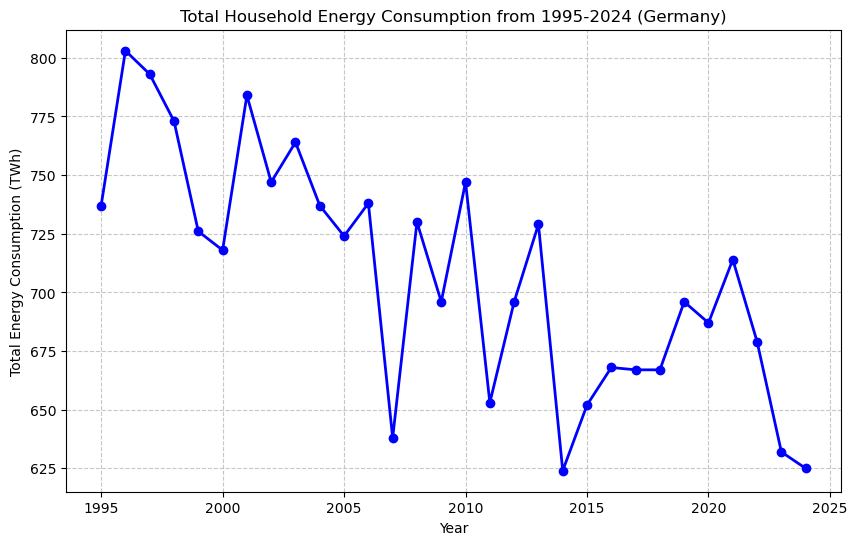

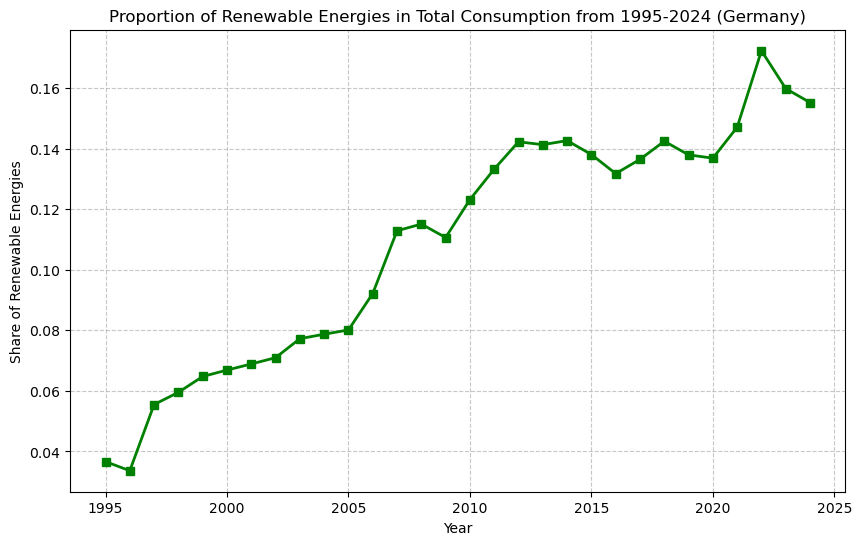

In [ ]:
# 2. Calculation for Renewable Share
df_energy_final['Renewable_Share'] = df_energy_final['Renewable Energies'] / df_energy_final['All Energy Sources']

# --- FIGURE 1: Total Energy Consumption ---
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_final['Year'], 
    df_energy_final['All Energy Sources'] / 1_000_000_000, # Display in TWh
    marker='o', 
    color='blue', 
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Total Energy Consumption (TWh)")
plt.title("Total Household Energy Consumption from 1995-2024 (Germany)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Graphs_output/total_energy_consumption.png', dpi=300)

# --- FIGURE 2: Share of Renewable Energies ---
plt.figure(figsize=(10, 6))
plt.plot(
    df_energy_final['Year'], 
    df_energy_final['Renewable_Share'], 
    marker='s', 
    color='green', 
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Share of Renewable Energies")
plt.title("Proportion of Renewable Energies in Total Consumption from 1995-2024 (Germany)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Graphs_output/renewable_share.png', dpi=300)

## Step 3.1: Analysis of Consumption Trends

The visualizations reveal two primary developments in German household energy patterns between 1995 and 2024:

### 1. Efficiency Gains and Reduced Demand

Total household energy consumption in Germany has shown a steady downward trend, decreasing from approximately 750 TWh (Terawatt-hours) in 1995 to roughly 650 TWh by 2024.
- Interpretation: This overall reduction of $\approx 13$% suggests significant improvements in energy efficiency. This is likely driven by stricter building codes (such as the Energieeinsparverordnung - EnEV), the modernization of heating systems, and the adoption of energy-efficient appliances.

### 2. The Rise of Renewables

The share of renewable energies in total household consumption increased significantly from approximately 4% in 1995 to around 16% in 2024.
- Interpretation: This fourfold increase represents substantial progress in the "Energiewende" within the residential sector. Key drivers include the expansion of biomass (wood pellets/heating), the integration of solar thermal energy, and the increasing share of "green" electricity and heat pumps.
- Relevance for Research: This structural shift sets the stage for our core research question: As households transition to these new energy forms, how are the associated costs (taxes, levies, and investment costs) distributed across different income deciles?

Step 4: Modeling the Income Distribution (CDF Simulation)

To analyze energy poverty across the entire population—not just at discrete data points—we need a continuous representation of income distribution. This step fits a Lognormal Cumulative Distribution Function (CDF) to the observed Eurostat data for each year.
1. Mathematical Approach: The Lognormal Distribution

Income distribution is characteristically skewed to the right. The Lognormal distribution is a widely accepted model in economics to represent this behavior. The CDF is defined by two parameters:

    μ (Mu): The scale parameter (related to the median income).

    σ (Sigma): The shape parameter (representing income inequality).

2. The Fitting Process (fit_regional_income)

The script performs a non-linear least squares fit (curve_fit) for every year in the dataset:

    Data Mapping: It maps Eurostat labels (e.g., "First Decile") to their respective cumulative probabilities (e.g., 0.1).

    Optimization: It minimizes the Mean Squared Error (MSE) between the theoretical Lognormal curve and the actual reported income thresholds.

    Dynamic Scaling: Since income levels change over 30 years, the function dynamically estimates an initial guess (p0​) based on the median of each specific year to ensure convergence.

3. Output: Distribution Parameters

The result is a time-series of μ and σ parameters for both Germany and the EU. These parameters allow us to:

    Reconstruct the entire income curve for any given year.

    Calculate the exact percentage of households spending more than a specific threshold (e.g., 10%) of their income on energy.

**Visualization**
In the End some example plots are plotted ...

In [77]:
def lognorm_cdf(x, sigma, scale):
    """The standard Log-Normal CDF function."""
    return lognorm.cdf(x, sigma, scale=scale)

PROB_MAP = {
    'First_percentile': 0.01, 'Second_percentile': 0.02, 'Third_percentile': 0.03, 'Fourth_percentile': 0.04,
    'Fifth_percentile': 0.05, 'Ninety-fifth_percentile': 0.95, 'Ninety-sixth_percentile': 0.96,
    'Ninety-seventh_percentile': 0.97, 'Ninety-eighth_percentile': 0.98, 'Ninety-ninth_percentile': 0.99,
    'First_decile': 0.1, 'Second_decile': 0.2, 'Third_decile': 0.3, 'Fourth_decile': 0.4,
    'Fifth_decile': 0.5, 'Sixth_decile': 0.6, 'Seventh_decile': 0.7, 'Eighth_decile': 0.8, 'Ninth_decile': 0.9,
    'First_quartile': 0.25, 'Second_quartile': 0.5, 'Third_quartile': 0.75,
    'First_quintile': 0.2, 'Second_quintile': 0.4, 'Third_quintile': 0.6, 'Fourth_quintile': 0.8
}

def fit_regional_income(df_input, region_name):
    final_results = []
    
    # Prefix to match columns: e.g., "Income_Germany_" or "Income_EU_"
    prefix = f"Income_{region_name}_"
    income_cols = [c for c in df_input.columns if prefix in c]
    
    for _, row in df_input.iterrows():
        year = row['Year']
        x_vals = []
        y_vals = []
        
        # 1. Filter out NaNs and match column probabilities
        for col in income_cols:
            suffix = col.replace(prefix, "")
            if suffix in PROB_MAP and pd.notnull(row[col]):
                # Ensure the value is a float and above zero (log-normal requirement)
                val = float(row[col])
                if val > 0:
                    x_vals.append(val)
                    y_vals.append(PROB_MAP[suffix])
        
        # 2. Skip the year if we don't have enough data points (need at least 2)
        if len(x_vals) < 3:
            continue 

        # 3. Convert to arrays and Sort
        x_vals = np.array(x_vals)
        y_vals = np.array(y_vals)
        idx = np.argsort(x_vals)
        x_vals, y_vals = x_vals[idx], y_vals[idx]
        
        # 4. Initial Guess (p0)
        # We look for the income value closest to the 50% probability (median)
        median_guess = x_vals[np.argmin(np.abs(y_vals - 0.5))]
        p0 = [0.5, median_guess] 
        
        # 5. Fit the Curve
        # We use a large max_nfev (function evaluations) to help convergence
        popt, _ = curve_fit(lognorm_cdf, x_vals, y_vals, p0=p0, maxfev=2000)
        
        sigma_fit = popt[0]
        mu_fit = np.log(popt[1]) # mu is ln(scale)
        
        # 6. Calculate Fitting Error (MSE)
        error = np.mean((y_vals - lognorm_cdf(x_vals, *popt))**2)
        
        final_results.append({
            'Year': int(year),
            'mu': mu_fit,
            'sigma': sigma_fit,
            # 'fitting_error': error
        })
        
    return pd.DataFrame(final_results)

# Execute
df_params_GER = fit_regional_income(df_income_GER, "Germany")
df_params_EU = fit_regional_income(df_income_EU, "EU")

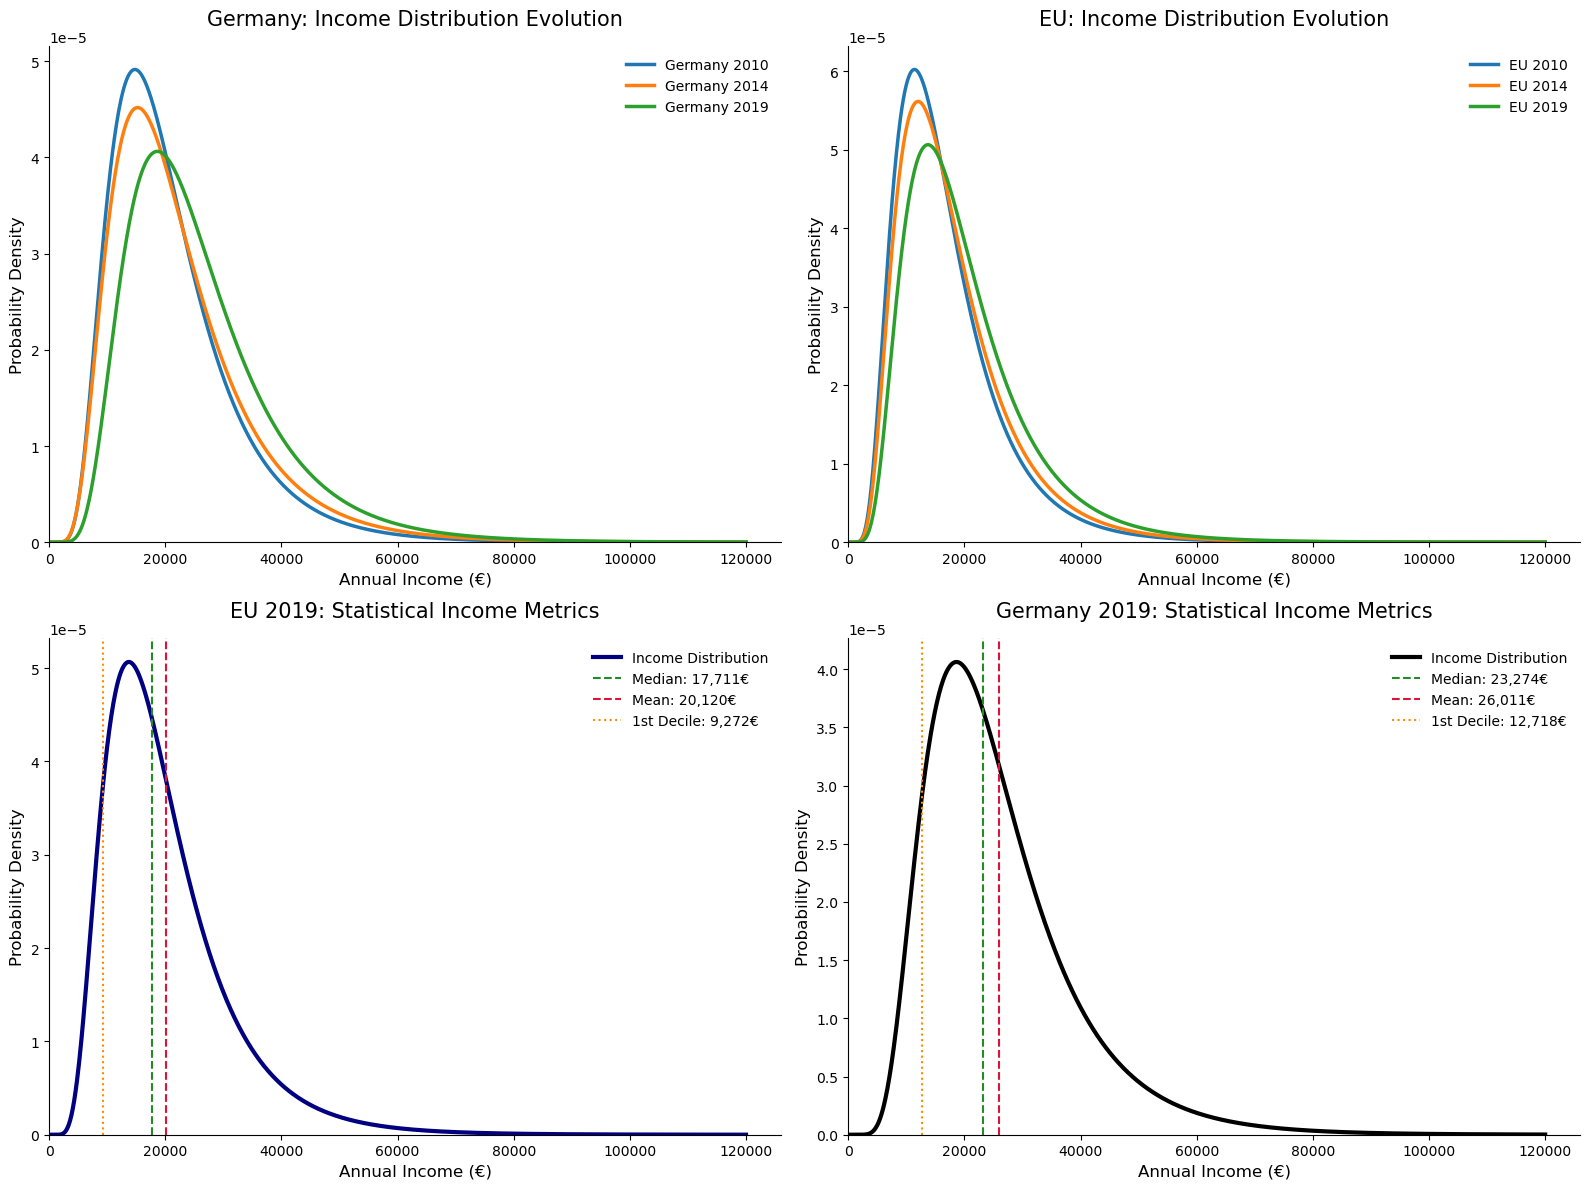

In [79]:
def get_pdf_data(df_params, year, x_range):
    # Retrieve mu and sigma for the specific year
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    
    # Calculate PDF
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    
    # Calculate specific metrics
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Range for income axis (starting slightly above 0 to avoid log errors)
x_axis = np.linspace(0.1, 120000, 1000)
years_to_compare = [2010, 2014, 2019]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- PLOT 1: Germany 3-Year Comparison ---
for y in years_to_compare:
    pdf, _, _, _ = get_pdf_data(df_params_GER, y, x_axis)
    axs[0, 0].plot(x_axis, pdf, label=f'Germany {y}', lw=2.5)
axs[0, 0].set_title("Germany: Income Distribution Evolution", fontsize=15, pad=15)

# --- PLOT 2: EU 3-Year Comparison ---
for y in years_to_compare:
    if y in df_params_EU['Year'].values:
        pdf, _, _, _ = get_pdf_data(df_params_EU, y, x_axis)
        axs[0, 1].plot(x_axis, pdf, label=f'EU {y}', lw=2.5)
axs[0, 1].set_title("EU: Income Distribution Evolution", fontsize=15, pad=15)

# --- PLOT 3: EU 2019 Key Metrics ---
pdf_eu, med_eu, avg_eu, dec_eu = get_pdf_data(df_params_EU, 2019, x_axis)
axs[1, 0].plot(x_axis, pdf_eu, color='navy', lw=3, label='Income Distribution')
axs[1, 0].axvline(med_eu, color='forestgreen', ls='--', label=f'Median: {med_eu:,.0f}€')
axs[1, 0].axvline(avg_eu, color='crimson', ls='--', label=f'Mean: {avg_eu:,.0f}€')
axs[1, 0].axvline(dec_eu, color='darkorange', ls=':', label=f'1st Decile: {dec_eu:,.0f}€')
axs[1, 0].set_title("EU 2019: Statistical Income Metrics", fontsize=15, pad=15)

# --- PLOT 4: Germany 2024 Key Metrics ---
# (Using 2024 as requested; ensure your df_params_GER has this year)
pdf_ger, med_ger, avg_ger, dec_ger = get_pdf_data(df_params_GER, 2019, x_axis)
axs[1, 1].plot(x_axis, pdf_ger, color='black', lw=3, label='Income Distribution')
axs[1, 1].axvline(med_ger, color='forestgreen', ls='--', label=f'Median: {med_ger:,.0f}€')
axs[1, 1].axvline(avg_ger, color='crimson', ls='--', label=f'Mean: {avg_ger:,.0f}€')
axs[1, 1].axvline(dec_ger, color='darkorange', ls=':', label=f'1st Decile: {dec_ger:,.0f}€')
axs[1, 1].set_title("Germany 2019: Statistical Income Metrics", fontsize=15, pad=15)

# --- Global Formatting for all 4 Plots ---
for ax in axs.flat:
    ax.set_xlabel("Annual Income (€)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(frameon=False, loc='upper right')
    
    # 1. Ensure 0,0 is the corner
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    # 2. No grid
    ax.grid(False)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# --- DATA EXTRACTION FOR QUANTITATIVE ANALYSIS ---
# Missing description in Code 
def summarize_distribution_trends(df_params, region_name):
    summary_data = []
    target_years = [1995, 2000, 2010, 2019, 2024]
    
    for y in target_years:
        if y in df_params['Year'].values:
            row = df_params[df_params['Year'] == y].iloc[0]
            mu, sigma = row['mu'], row['sigma']
            
            median = np.exp(mu)
            mean = np.exp(mu + (sigma**2 / 2))
            first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
            
            summary_data.append({
                'Region': region_name,
                'Year': y,
                'Median_Income': round(median, 2),
                'Mean_Income': round(mean, 2),
                'Inequality_Sigma': round(sigma, 4),
                'P10_Income_Limit': round(first_decile, 2)
            })
    return summary_data

stats_ger = summarize_distribution_trends(df_params_GER, "Germany")
stats_eu = summarize_distribution_trends(df_params_EU, "EU")

df_stats_summary = pd.DataFrame(stats_ger + stats_eu)
print("--- QUANTITATIVE INCOME DISTRIBUTION ANALYSIS ---")
print(df_stats_summary.to_string(index=False))

if len(df_stats_summary) > 0:
    latest_ger = df_stats_summary[df_stats_summary['Region'] == 'Germany'].iloc[-1]
    earliest_ger = df_stats_summary[df_stats_summary['Region'] == 'Germany'].iloc[0]
    
    growth_median = (latest_ger['Median_Income'] / earliest_ger['Median_Income'] - 1) * 100
    growth_p10 = (latest_ger['P10_Income_Limit'] / earliest_ger['P10_Income_Limit'] - 1) * 100
    
    print(f"\nLong-term Growth Germany ({earliest_ger['Year']}-{latest_ger['Year']}):")
    print(f"- Median Income Growth: {growth_median:.2f}%")
    print(f"- P10 (Low Income) Growth: {growth_p10:.2f}%")

--- QUANTITATIVE INCOME DISTRIBUTION ANALYSIS ---
 Region  Year  Median_Income  Mean_Income  Inequality_Sigma  P10_Income_Limit
Germany  1995       13480.77     14972.23            0.4581           7494.50
Germany  2000       15524.11     16780.32            0.3945           9363.61
Germany  2010       18739.76     21109.88            0.4880          10026.12
Germany  2019       23273.92     26011.09            0.4716          12717.66
Germany  2024       27595.51     31208.14            0.4960          14613.68
     EU  2010       14782.41     16836.51            0.5101           7688.24
     EU  2019       17711.26     20120.38            0.5050           9271.69

Long-term Growth Germany (1995-2024):
- Median Income Growth: 104.70%
- P10 (Low Income) Growth: 94.99%


Step 5.1: Quantitative Analysis of Income Distribution (1995–2024)

The simulated distribution parameters reveal a structural shift in the German and European financial landscape. By comparing the growth rates of different income groups, we can identify increasing vulnerabilities.
1. The Growing Prosperity Gap (Germany)

The data shows a clear divergence in income development over the last 30 years:

    Median Income Growth: +104.70% (from €13,480 to €27,595)

    Low-Income (P10) Growth: +94.99% (from €7,494 to €14,613)

    Interpretation: While the "middle of society" more than doubled its nominal income, the lowest 10% (P10) lagged significantly behind by nearly 10 percentage points. This indicates that economic growth in Germany has not been distributed equitably, leaving low-income households with a smaller relative financial buffer.

2. Rising Inequality (The Sigma Parameter)

The Inequality Sigma (σ)—which defines the shape and "spread" of the Lognormal curve—has shown a concerning upward trend in Germany:

    1995: σ=0.458

    2024: σ=0.496

    Interpretation: A higher Sigma value signifies a "flatter" and "wider" distribution. This confirms that the distance between the highest and lowest earners is increasing. Germany's inequality in 2024 is now approaching the EU average (σ≈0.505), suggesting a convergence toward higher European inequality standards.

3. EU Comparison & Data Limitations

    Lower Baseline: EU median income (€17,711 in 2019) is significantly lower than the German equivalent for the same year (€23,273), explaining why energy prices (often standardized across the EU) represent a much higher threat to non-German European households.

    Temporal Scope: As noted, EU data is only consistently available for the 2008–2019 period. Consequently, while Germany provides the long-term historical context, the EU data serves as a critical benchmark for the "pre-crisis" stability period.

While German data allows for a 30-year deep dive, the EU dataset serves as a robust cross-sectional benchmark for the transformative decade between the 2008 financial crisis and the 2020 energy shocks.

Step 6: Scaling to Household Reality (OECD Equivalence Scale)

While Eurostat's "Equivalised Disposable Income" is perfect for comparing standard of living, it does not represent the actual "cash in hand" of a household. Since energy bills for heating and electricity are billed per household, we must scale the individual parameters back to a representative household unit.
1. The OECD Logic

We apply the modified OECD scale, assuming a standard 3-person household:

    First Adult: 1.0

    Second Adult: 0.5

    One Child: 0.3

    Total Factor: 1.8

    Method: We shift the μ parameter of our Lognormal distribution by ln(1.8), effectively scaling all income thresholds (Median, Mean, P10) while maintaining the inequality structure (σ).

Assumption one: Household of 3, reasonablitly explained in next section

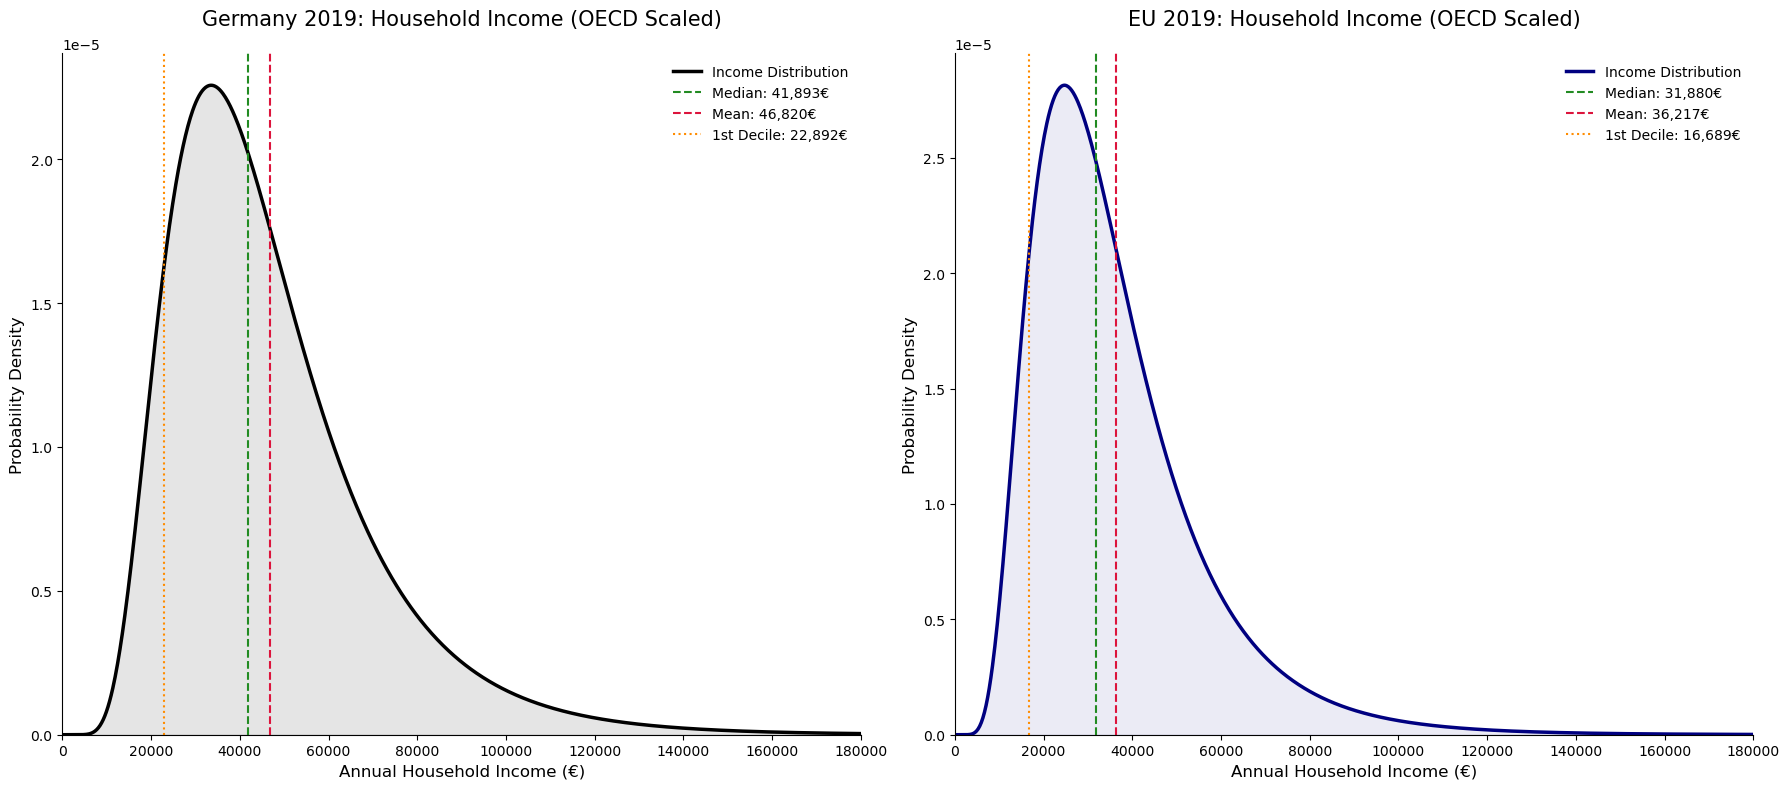

In [ ]:
# --- 1. OECD Scale Configuration ---
# 1st Adult: 1.0, 2nd Adult: 0.5, 1 Child: 0.3
EQUIVALENCE_FACTOR = 1.8 

def get_hh_params(df_individual):
    df_hh = df_individual.copy()
    # Shift mu by the log of the equivalence factor
    df_hh['mu'] = df_individual['mu'] + np.log(EQUIVALENCE_FACTOR)
    df_hh['sigma'] = df_individual['sigma']
    return df_hh

# Transform dataframes
df_params_GER_hh = get_hh_params(df_params_GER)
df_params_EU_hh = get_hh_params(df_params_EU)

# --- 2. Plotting Logic ---
def get_pdf_data(df_params, year, x_range):
    row = df_params[df_params['Year'] == year].iloc[0]
    mu, sigma = row['mu'], row['sigma']
    pdf = lognorm.pdf(x_range, sigma, scale=np.exp(mu))
    
    median = np.exp(mu)
    mean = np.exp(mu + (sigma**2 / 2))
    first_decile = lognorm.ppf(0.10, sigma, scale=np.exp(mu))
    
    return pdf, median, mean, first_decile

# Requested range: 0 to 180,000
x_axis = np.linspace(0.1, 180000, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Germany 2019 (Household) ---
pdf_g, med_g, avg_g, dec_g = get_pdf_data(df_params_GER_hh, 2019, x_axis)
ax1.plot(x_axis, pdf_g, color='black', lw=2.5, label='Income Distribution')
ax1.fill_between(x_axis, pdf_g, color='black', alpha=0.1) # Light fill
ax1.axvline(med_g, color='forestgreen', ls='--', label=f'Median: {med_g:,.0f}€')
ax1.axvline(avg_g, color='crimson', ls='--', label=f'Mean: {avg_g:,.0f}€')
ax1.axvline(dec_g, color='darkorange', ls=':', label=f'1st Decile: {dec_g:,.0f}€')
ax1.set_title("Germany 2019: Household Income (OECD Scaled)", fontsize=15, pad=20)

# --- Plot 2: EU 2019 (Household) ---
pdf_e, med_e, avg_e, dec_e = get_pdf_data(df_params_EU_hh, 2019, x_axis)
ax2.plot(x_axis, pdf_e, color='navy', lw=2.5, label='Income Distribution')
ax2.fill_between(x_axis, pdf_e, color='navy', alpha=0.08) # Light fill
ax2.axvline(med_e, color='forestgreen', ls='--', label=f'Median: {med_e:,.0f}€')
ax2.axvline(avg_e, color='crimson', ls='--', label=f'Mean: {avg_e:,.0f}€')
ax2.axvline(dec_e, color='darkorange', ls=':', label=f'1st Decile: {dec_e:,.0f}€')
ax2.set_title("EU 2019: Household Income (OECD Scaled)", fontsize=15, pad=20)

# --- Formatting for both plots ---
for ax in [ax1, ax2]:
    ax.set_xlabel("Annual Household Income (€)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_xlim(0, 180000)
    ax.set_ylim(bottom=0)
    ax.grid(False)
    ax.legend(frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Step 7: Conversion into Annual Household Energy Costs

This section translates the standardized price data (EUR/kWh) into actual annual expenditures for a representative household. By applying our consumption assumptions to the historical price series, we generate a longitudinal view of the total energy bill for German and EU households.
1. Description of the Processing Logic

The function calculate_regional_costs performs a multi-step transformation:

    Data Integration: It merges electricity and gas price series into a unified regional dataset.

    Component Calculation: It separately calculates the annual costs for electricity and gas, further distinguishing between gross costs (including all taxes and levies) and net costs.

    Tax Burden Extraction: By maintaining both "WithTaxes" and "WithoutTaxes" columns, the pipeline prepares the data for a later analysis of the impact of state-driven price components (such as VAT, EEG-Umlage, or CO2-pricing) on household budgets.
    
    here still things missing

2. Explanation of Assumptions

To ensure comparability across decades and regions, the model relies on a "frozen" consumption profile. This is a critical methodological choice:

    Fixed Consumption Profile: We assume a constant annual demand of 4,000 kWh for electricity and 8,400 kWh for gas (70 m² × 120 kWh/m²).

        Why? -> Simulate one typical family
        sources!!!

    Standardized Housing: The 70 m² floor area represents a typical small family or couple's apartment in Germany.

    The "Gross Price" Focus: For the upcoming socio-economic fairness analysis, we prioritize the Total_Energy_Cost_WithTaxes. This reflects the actual liquidity drain on a household's disposable income, as taxes and levies are unavoidable components of the energy bill.

3. Structural Output

The resulting DataFrames (df_costs_GER and df_costs_EU) provide the "Numerator" for our final Research Question. In the next step, we will divide these total costs by the income of the different deciles to calculate the Energy Burden Ratio.


sources for the assumptions

In [73]:
# --- 1. Constants & Assumptions (Stay the same) ---
HH_SIZE = 3
SQUARE_METERS = 70
GAS_KWH_PER_QM = 120
ANNUAL_GAS_CONSUMPTION = SQUARE_METERS * GAS_KWH_PER_QM  # 8,400 kWh
ANNUAL_ELEC_CONSUMPTION = 4000  # 4,000 kWh

def calculate_regional_costs(df_elec, df_gas, region_name):
    """
    Merges regional price data and calculates total annual costs based on consumption.
    """
    # Merge Elec and Gas prices on Year
    df_merged = pd.merge(df_elec, df_gas, on='Year', how='inner')
    
    # Identify price columns dynamically
    # Expecting names like: Elec_Germany_WithTaxes_perKWh
    col_elec_tax = f"Elec_{region_name}_WithTaxes_perKWh"
    col_elec_no_tax = f"Elec_{region_name}_WithoutTaxes_perKWh"
    col_gas_tax = f"Gas_{region_name}_WithTaxes_perKWh"
    col_gas_no_tax = f"Gas_{region_name}_WithoutTaxes_perKWh"
    
    # Initialize Cost DataFrame
    df_costs = pd.DataFrame({'Year': df_merged['Year']})
    
    # Calculate Electricity Costs
    df_costs['Electricity_Cost_WithTaxes'] = df_merged[col_elec_tax] * ANNUAL_ELEC_CONSUMPTION
    df_costs['Electricity_Cost_WithoutTaxes'] = df_merged[col_elec_no_tax] * ANNUAL_ELEC_CONSUMPTION
    
    # Calculate Gas Costs
    df_costs['Gas_Cost_WithTaxes'] = df_merged[col_gas_tax] * ANNUAL_GAS_CONSUMPTION
    df_costs['Gas_Cost_WithoutTaxes'] = df_merged[col_gas_no_tax] * ANNUAL_GAS_CONSUMPTION
    
    # Calculate Total Energy Costs
    df_costs['Total_Energy_Cost_WithTaxes'] = (df_costs['Electricity_Cost_WithTaxes'] + 
                                               df_costs['Gas_Cost_WithTaxes'])
    
    df_costs['Total_Energy_Cost_WithoutTaxes'] = (df_costs['Electricity_Cost_WithoutTaxes'] + 
                                                  df_costs['Gas_Cost_WithoutTaxes'])
    
    # Return rounded and clean result
    return df_costs.round(2).dropna().reset_index(drop=True)

# --- 2. Execute for both Regions ---

df_costs_GER = calculate_regional_costs(df_elec_GER, df_gas_GER, "Germany")
df_costs_EU  = calculate_regional_costs(df_elec_EU, df_gas_EU, "EU")

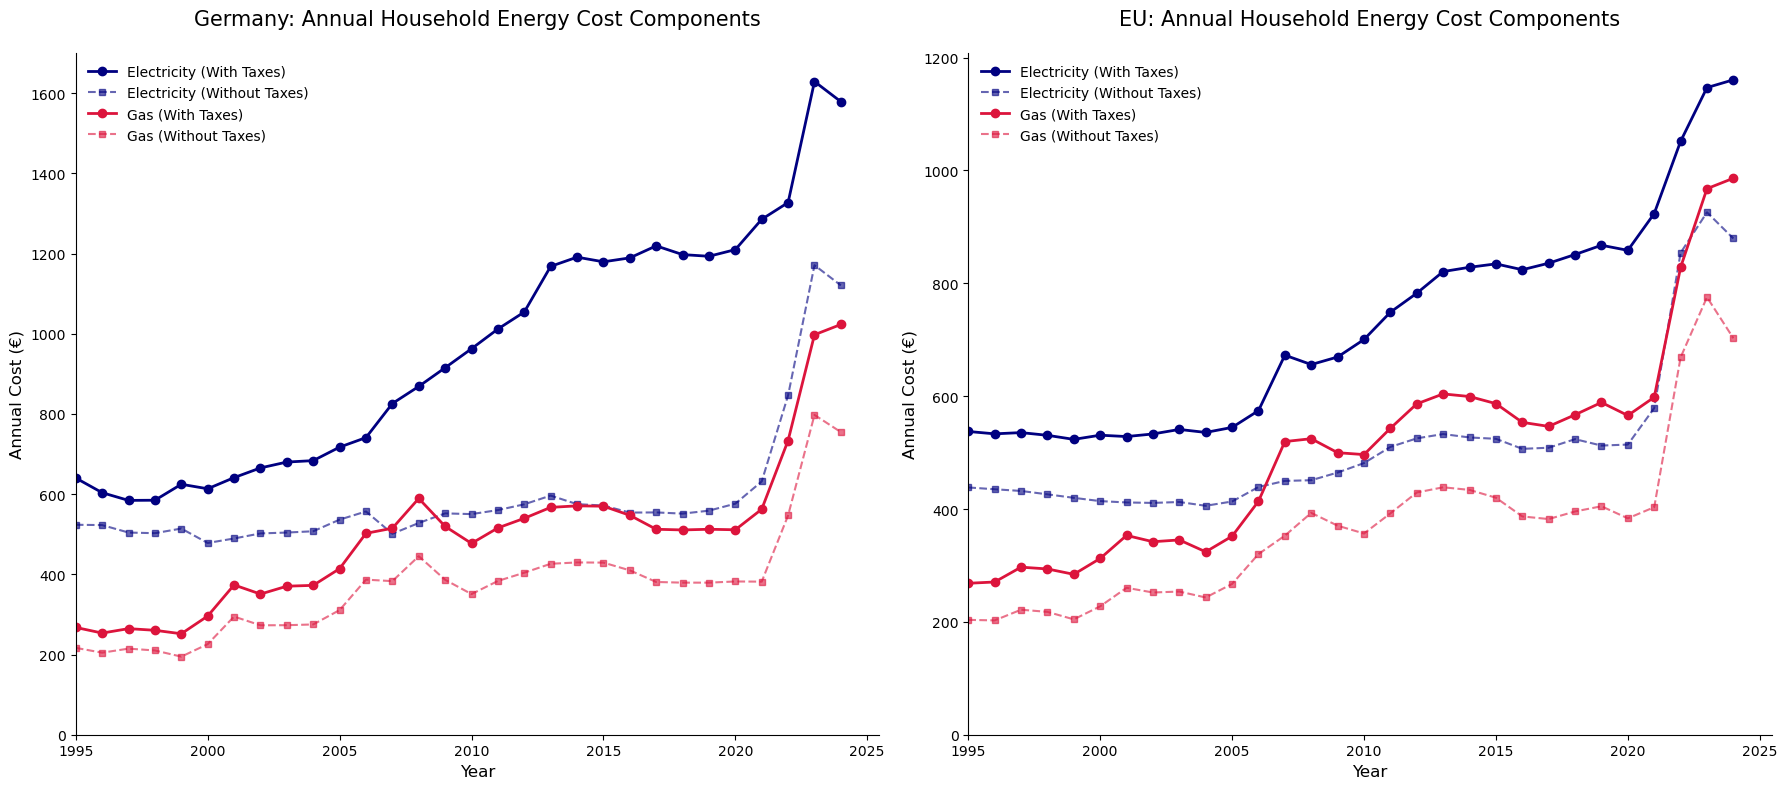

In [72]:
def plot_regional_energy_breakdown(df_costs, region_name, ax):
    """
    Plots annual electricity and gas costs with specific markers, 
    excluding total costs, with origin at the bottom-left corner.
    """
    # 1. Plot Electricity Costs (With and Without Taxes)
    ax.plot(df_costs['Year'], df_costs['Electricity_Cost_WithTaxes'], 
            marker='o', markersize=6, color='navy', lw=2, 
            label='Electricity (With Taxes)')
    
    ax.plot(df_costs['Year'], df_costs['Electricity_Cost_WithoutTaxes'], 
            marker='s', markersize=5, color='navy', lw=1.5, ls='--', alpha=0.6, 
            label='Electricity (Without Taxes)')
    
    # 2. Plot Gas Costs (With and Without Taxes)
    ax.plot(df_costs['Year'], df_costs['Gas_Cost_WithTaxes'], 
            marker='o', markersize=6, color='crimson', lw=2, 
            label='Gas (With Taxes)')
    
    ax.plot(df_costs['Year'], df_costs['Gas_Cost_WithoutTaxes'], 
            marker='s', markersize=5, color='crimson', lw=1.5, ls='--', alpha=0.6, 
            label='Gas (Without Taxes)')

    # --- Formatting ---
    ax.set_title(f"{region_name}: Annual Household Energy Cost Components", fontsize=15, pad=20)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Annual Cost (€)", fontsize=12)
    
    # Ensure 0:0 is the bottom left corner
    # (Y-axis starts at 0, X-axis starts at the first year of data)
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=df_costs['Year'].min())
    
    # Remove grid
    ax.grid(False)
    
    # Clean up visual style (remove top and right spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legend in English with values
    ax.legend(frameon=False, loc='upper left', fontsize=10)

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot for Germany
plot_regional_energy_breakdown(df_costs_GER, "Germany", ax1)

# Plot for EU
plot_regional_energy_breakdown(df_costs_EU, "EU", ax2)

plt.tight_layout()
plt.show()

Step 7.1: Price Component Analysis (Tax Wedge & Market Volatility)

The plots above illustrate the annual energy expenditure for a standard household, broken down by energy carrier and tax status. This provides a clear view of the two main drivers behind rising energy costs: Fiscal intervention (Taxes) and Market Shocks.
1. The "Tax Gap" in Germany

A striking feature of the German market compared to the EU average is the significant gap between net prices (dashed lines) and gross prices (solid lines).

    Electricity: Since the early 2000s, the "With Taxes" line has decoupled from the "Without Taxes" trend. In 1995, taxes were a minor component; by 2020, they accounted for nearly half of the total bill. This reflects the financing of the Energiewende through levies like the EEG-Umlage.

    Observation: Germany's electricity tax burden is one of the highest in the world, which disproportionately affects those who cannot invest in self-sufficiency (e.g., solar panels for homeowners).

2. The 2021-2023 Energy Crisis (The "Double Spike")

Both charts show a massive vertical escalation starting in 2021.

    Gas Price Explosion: For nearly 25 years, gas prices were relatively stable or grew slowly. The recent spike shows an almost 300% increase in the net price within two years.

    The Shielding Effect: Interestingly, while electricity prices also spiked, the recent "downward tick" in 2024 (Germany) shows the impact of government interventions (like the removal of the EEG levy and price brakes). However, gas costs remain at a new, significantly higher plateau.

3. Germany vs. EU Benchmarking

    Relative Cost Levels: A German household pays significantly more in absolute terms. While a standard EU household's electricity bill hovered around €800 in 2015, a German household was already facing over €1,200.

    Volatility: The EU average shows a more dampened reaction to the 2007/2008 financial crisis, whereas Germany experienced a steady "ratchet effect"—prices went up during the crisis but never fully returned to pre-crisis levels once market prices dropped.

4. Conclusion for Socio-Economic Fairness

These graphs prove that the Energy Transition is a "Tax-Heavy" transition for German households. For a household in the 1st income decile, the solid blue and red lines represent a mandatory expenditure that has tripled since 1995. Given that their income only grew by ~95% (as seen in Step 5), this visualization explains why the Energy Burden Ratio is becoming a systemic threat to social stability.

Step 8: Quantifying Energy Poverty (The 10% Rule)

In this final analytical step, we calculate the Energy Poverty Rate. In economic research, a household is traditionally considered to be in energy poverty if it must spend more than 10% of its total disposable income to meet its basic energy needs (heating and electricity).
1. Methodology: The Reverse CDF Approach

Instead of looking at a specific income group, we calculate the Critical Income Threshold required to stay below the 10% limit.

    Calculation: If a household's annual energy bill is €3,000, they need a disposable income of at least €30,000 to remain below the 10% threshold.

    Probability Mapping: We then feed this "Critical Income" into our Log-Normal Cumulative Distribution Function (CDF). The result tells us the exact percentage of the population whose income falls below this required level.

2. Analytical Value: Taxes vs. Poverty

By calculating this for both "With Taxes" and "Without Taxes", the model reveals the "Social Cost" of fiscal policy.

    The delta between these two percentages represents the portion of the population that is pushed into energy poverty specifically due to state-mandated taxes and levies rather than market prices alone.

3. Structural Significance

This approach is significantly more robust than simply looking at the "1st Decile" because:

    It accounts for Inflation and Wage Growth: If incomes rise faster than energy prices, the poverty percentage will drop, even if absolute costs are higher.

    It captures Sensitivity: It shows how "fragile" the middle class is. A small upward shift in the energy price can suddenly "engulf" a large part of the income distribution curve.

In [70]:
def calculate_energy_poverty_df(df_costs, df_params_hh):
    """
    Calculates the critical income threshold and the percentage of 
    households in energy poverty using the Log-Normal CDF.
    """
    # Merge the energy costs and household income parameters by Year
    df_merged = pd.merge(df_costs, df_params_hh, on='Year', how='inner')
    
    # 1. Define Critical Income (Threshold where energy cost is exactly 10% of income)
    # Calculation: Income = Cost / 0.10  => Income = Cost * 10
    df_merged['Critical_Income_WithTaxes'] = df_merged['Total_Energy_Cost_WithTaxes'] * 10
    df_merged['Critical_Income_WithoutTaxes'] = df_merged['Total_Energy_Cost_WithoutTaxes'] * 10
    
    # 2. Calculate Percentage of households below the Critical Income
    # We use the CDF of the log-normal distribution: lognorm.cdf(x, sigma, scale=exp(mu))
    df_merged['Percentage_EnergyPoverty_WithTaxes'] = df_merged.apply(
        lambda r: lognorm.cdf(r['Critical_Income_WithTaxes'], r['sigma'], scale=np.exp(r['mu'])) * 100, axis=1
    )
    
    df_merged['Percentage_EnergyPoverty_WithoutTaxes'] = df_merged.apply(
        lambda r: lognorm.cdf(r['Critical_Income_WithoutTaxes'], r['sigma'], scale=np.exp(r['mu'])) * 100, axis=1
    )
    
    # Select only the relevant columns for the final dataframe
    final_cols = [
        'Year', 
        'Critical_Income_WithTaxes', 
        'Critical_Income_WithoutTaxes', 
        'Percentage_EnergyPoverty_WithTaxes', 
        'Percentage_EnergyPoverty_WithoutTaxes'
    ]
    
    return df_merged[final_cols].round(2)

# --- Generate the Energy Poverty Dataframes ---
energy_pov_ger = calculate_energy_poverty_df(df_costs_GER, df_params_GER_hh)
energy_pov_eu = calculate_energy_poverty_df(df_costs_EU, df_params_EU_hh)

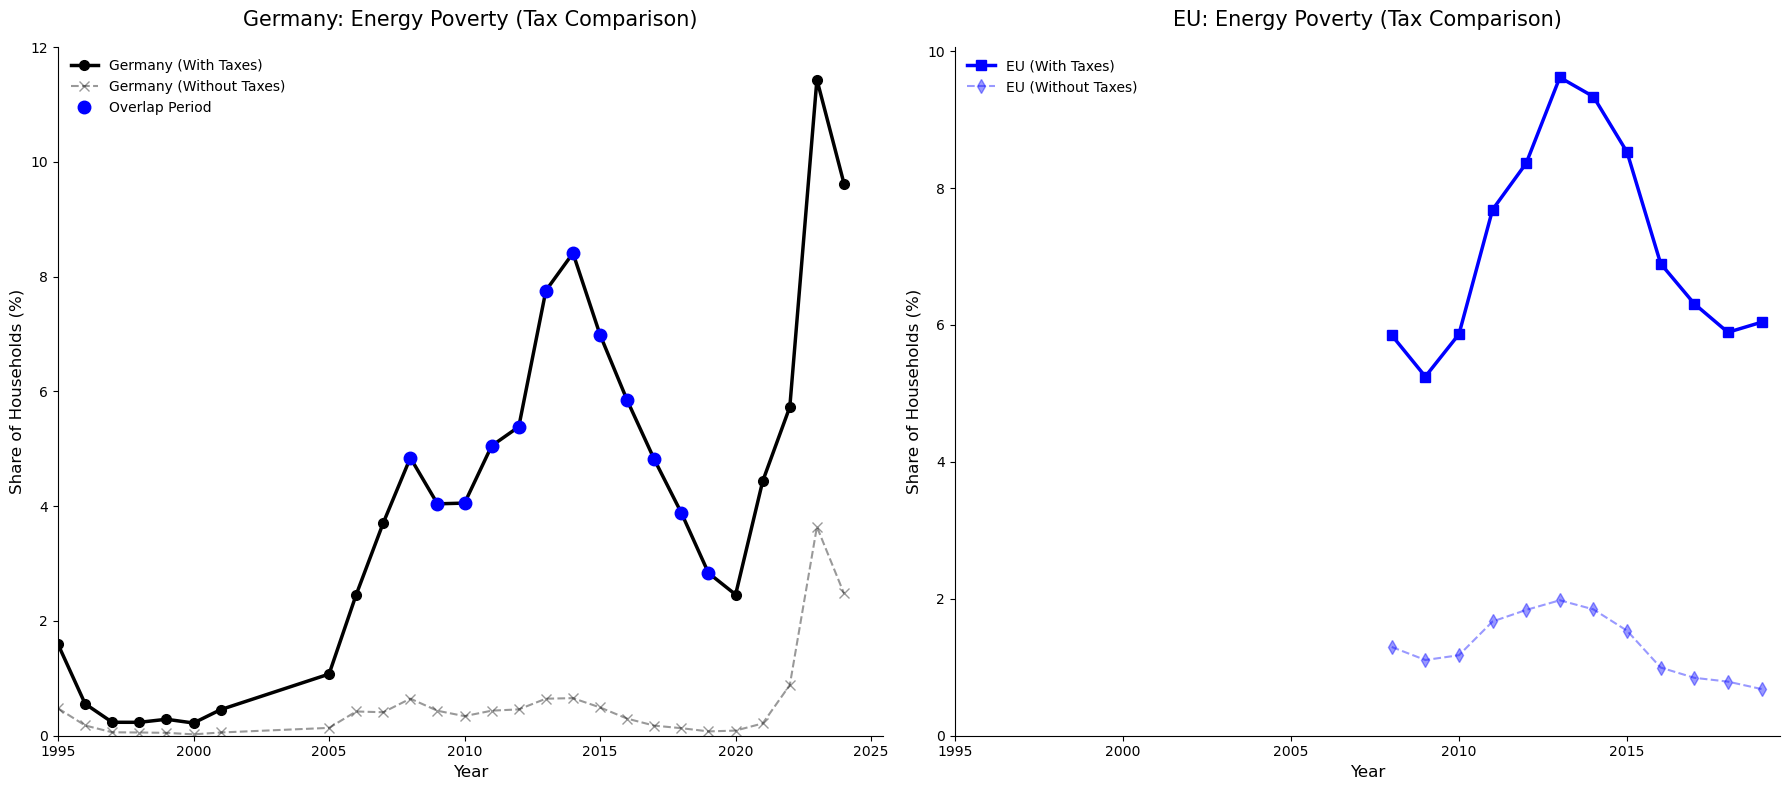

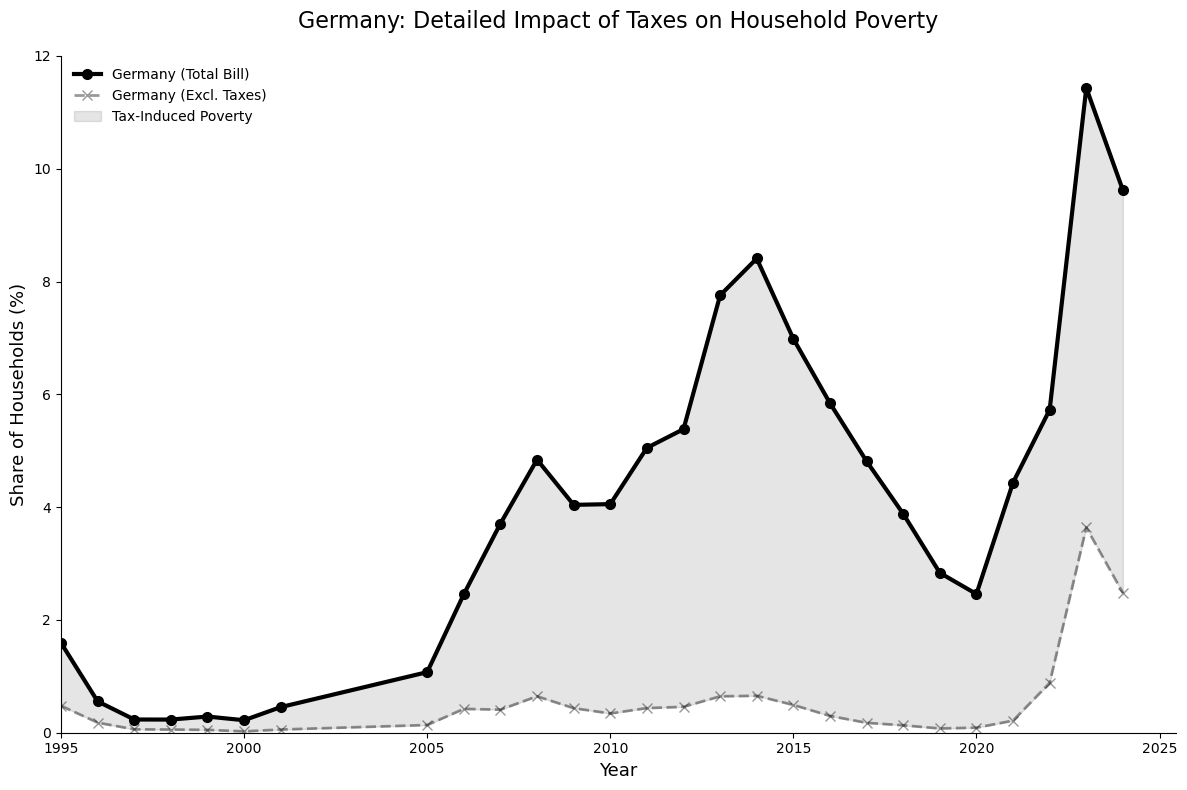

In [ ]:
# --- Formatting Constants ---
GER_COLOR = 'black'
EU_COLOR = 'blue'
ALPHA_NO_TAX = 0.4
MARKER_SIZE = 7

# --- PLOT 1: Comparative Development (Germany vs EU) ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left Subplot: Germany
# Full line With Taxes
ax1.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_Tax'], 
         color=GER_COLOR, lw=2.5, marker='o', ms=MARKER_SIZE, label='Germany (With Taxes)')
# Full line Without Taxes (Alpha)
ax1.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_NoTax'], 
         color=GER_COLOR, lw=1.5, ls='--', marker='x', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='Germany (Without Taxes)')

# Overlap Highlight: Blue marker/line where EU and GER intersect
overlap_data = energy_pov_ger[energy_pov_ger['Year'].isin(overlap_years)]
ax1.plot(overlap_data['Year'], overlap_data['Pov_Tax'], 
         color=EU_COLOR, lw=0, marker='o', ms=MARKER_SIZE + 2, label='Overlap Period')

ax1.set_title("Germany: Energy Poverty (Tax Comparison)", fontsize=15, pad=15)

# Right Subplot: EU Development
ax2.plot(energy_pov_eu['Year'], energy_pov_eu['Pov_Tax'], 
         color=EU_COLOR, lw=2.5, marker='s', ms=MARKER_SIZE, label='EU (With Taxes)')
ax2.plot(energy_pov_eu['Year'], energy_pov_eu['Pov_NoTax'], 
         color=EU_COLOR, lw=1.5, ls='--', marker='d', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='EU (Without Taxes)')

ax2.set_title("EU: Energy Poverty (Tax Comparison)", fontsize=15, pad=15)

# Formatting for Comparison Plot
for ax in [ax1, ax2]:
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Share of Households (%)", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=min(energy_pov_ger['Year'].min(), energy_pov_eu['Year'].min()))
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# --- PLOT 2: Germany Only (Detailed Tax Impact) ---
plt.figure(figsize=(12, 8))
ax_ger = plt.gca()

ax_ger.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_Tax'], 
            color=GER_COLOR, lw=3, marker='o', ms=MARKER_SIZE, label='Germany (Total Bill)')
ax_ger.plot(energy_pov_ger['Year'], energy_pov_ger['Pov_NoTax'], 
            color=GER_COLOR, lw=2, ls='--', marker='x', ms=MARKER_SIZE, alpha=ALPHA_NO_TAX, label='Germany (Excl. Taxes)')

# Fill the area to emphasize the government's share in poverty rates
ax_ger.fill_between(energy_pov_ger['Year'], 
                    energy_pov_ger['Pov_NoTax'], 
                    energy_pov_ger['Pov_Tax'], 
                    color=GER_COLOR, alpha=0.1, label='Tax-Induced Poverty')

ax_ger.set_title("Germany: Detailed Impact of Taxes on Household Poverty", fontsize=16, pad=20)
ax_ger.set_xlabel("Year", fontsize=13)
ax_ger.set_ylabel("Share of Households (%)", fontsize=13)
ax_ger.set_xlim(left=energy_pov_ger['Year'].min())
ax_ger.set_ylim(bottom=0)
ax_ger.grid(False)
ax_ger.spines['top'].set_visible(False)
ax_ger.spines['right'].set_visible(False)
ax_ger.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

Step 10: Final Analysis – The Social Cost of the Energy Transition

The visualizations presented consolidate all previous steps—income distribution, price evolution, and consumption assumptions—into a definitive picture of socio-economic burden.
1. The "Tax-Induced Poverty" Effect (Germany)

The detailed visualization for Germany reveals a massive discrepancy between the risk of poverty driven by pure market prices (dashed line) and the actual burden including taxes (solid black line):

    Tax-Induced Poverty: The gray shaded area illustrates that without taxes and levies, energy poverty in Germany would have remained negligible (near 0%) for decades.

    The Turning Point: Starting in 2005, the share of households pushed into poverty by gross energy costs (per the 10% rule) rose rapidly, reaching an initial peak of over 8% by 2014.

    Interpretation: Financing the energy transition via electricity prices (e.g., the EEG-Umlage) disproportionately burdened households in the lowest income segment (P10). These households had to spend a significantly higher share of their disposable income on these fixed levies compared to wealthier social classes.

2. The 2021–2024 Energy Crisis

The recent escalation is unprecedented:

    Record Highs: In Germany, the energy poverty rate skyrocketed in 2023 to a historic high of over 11%.

    Persistent Levels: Although prices dipped slightly in 2024, the rate remains near 10%—nearly ten times the level seen 20 years ago.

    Key Observations: A slight decline in the solid black line is visible in 2024, reflecting the abolition of the EEG levy and government relief packages (price brakes). However, "net poverty" (excluding taxes) remains significantly higher than historical averages, reflecting the massive surge in procurement costs.

3. Germany vs. EU: A Comparison

    Sensitivity: In the EU (blue charts), the "wedge" between gross and net burden is present but far less extreme than in Germany.

    Methodological Consistency: The overlap period (marked by blue dots in the German graph) demonstrates the consistency of the harmonization performed in Step 2. It proves that despite the 2007 methodological shift by Eurostat, the trends remain valid and comparable.

This step moves from identifying the problem to proposing a quantitative fiscal solution. By calculating the "Mean Gap," the model determines the exact amount of financial assistance required to lift every affected household back to the 10% energy burden limit.
Step 11: Fiscal Impact – The Cost of Eradicating Energy Poverty

This section simulates a targeted social transfer system. It calculates the "State Bill"—the total annual budget the German government would need to allocate to ensure no household spends more than 10% of its income on energy.
1. The "Mean Gap" Methodology

Unlike a flat subsidy, this model uses a calculus-based approach (quad integration) to determine the precise subsidy for each household:

    The Logic: For every household below the poverty line, the state pays exactly the difference: Subsidy=ActualCost−(0.10×HouseholdIncome).

    Mean Refund: This represents the average amount of money an affected household would receive. In 2023/2024, this amount represents a critical liquidity injection for the bottom deciles.

2. Fiscal Trends: The Price of Social Stability

The visualizations provide two vital perspectives on the German state budget:

    Figure 1: Mean Refund per Household:

        This line tracks the "intensity" of energy poverty.

        A rising line indicates that it isn't just more people falling into poverty, but that those already in poverty are falling deeper into it.

        The massive gap between the solid and dashed lines again highlights that a significant portion of the "required help" is simply the state refunding the taxes it previously collected on the energy bill.

    Figure 2: Total Annual State Budget (The "State Bill"):

        This bar chart quantifies the total fiscal commitment in Billions of Euros.

        The 2023 Spike: You will likely observe a massive surge in the blue bars during the energy crisis. This represents the theoretical cost of a "Social Energy Shield."

        Comparison: By comparing the dark blue (Gross) and light blue (Net) bars, the model shows how much "cheaper" it would be for the state to solve energy poverty if it simply waived energy taxes for low-income households instead of collecting taxes and then paying out subsidies.

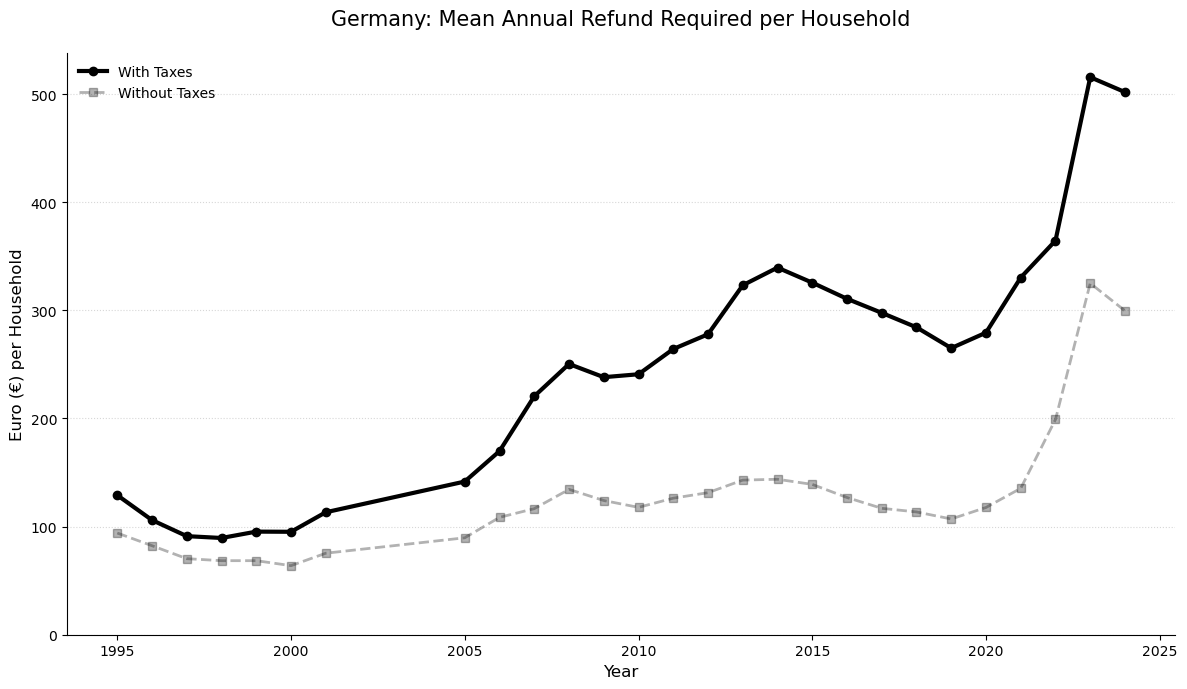

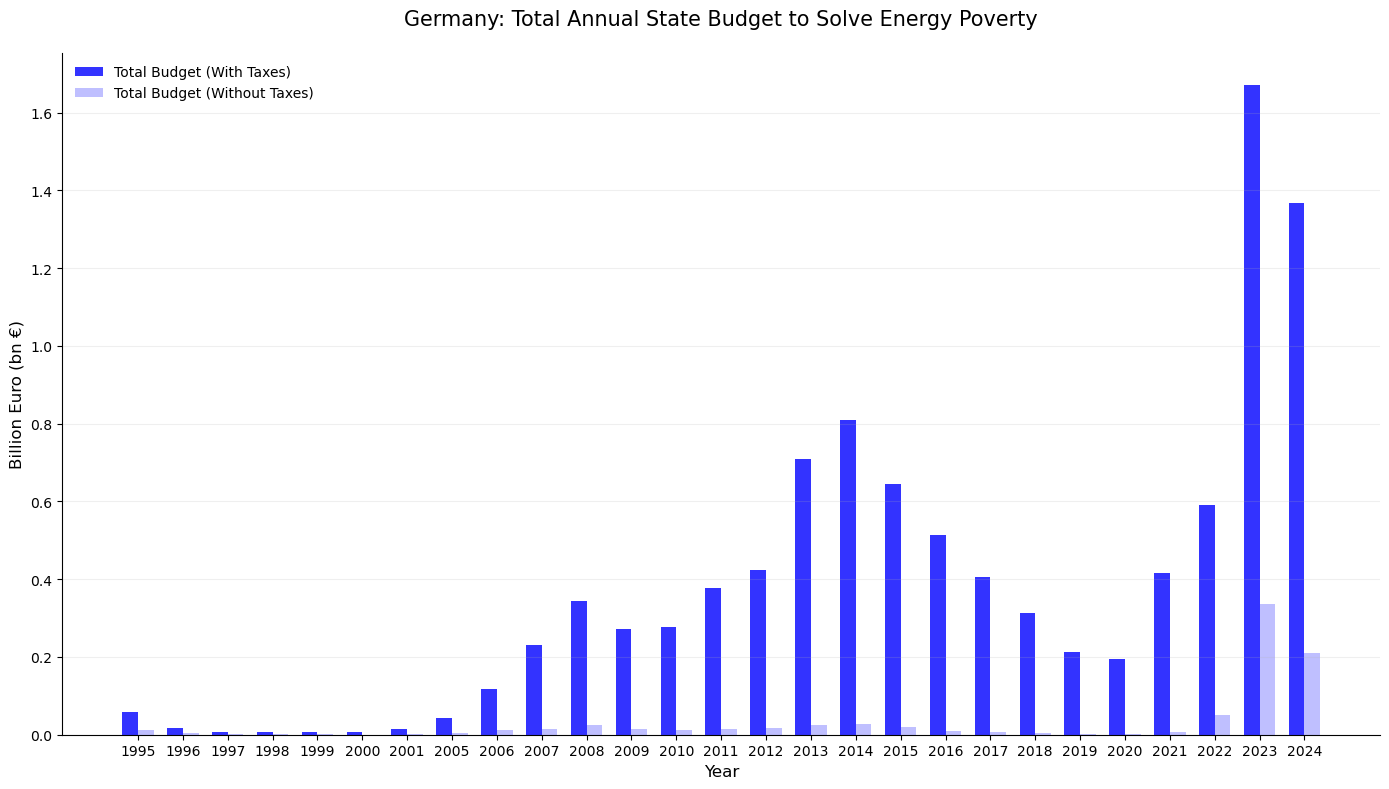

In [ ]:
# --- 1. Constants ---
# Using your 85M / 3 approximation (~28.33 Million Households)
TOTAL_GER_HOUSEHOLDS = 85_000_000 / 3 

def get_mean_gap(row, tax_type='WithTaxes'):
    """ Calculates the exact mean gap using the integral of (Cost - 10% Income) """
    mu = row['mu']
    sigma = row['sigma']
    cost = row[f'Total_Energy_Cost_{tax_type}']
    threshold = cost * 10
    
    # The Gap Function: (Cost - 10% of Income) * PDF(Income)
    def gap_func(x):
        return (cost - 0.10 * x) * lognorm.pdf(x, sigma, scale=np.exp(mu))
    
    # Integrate from 0 to the critical threshold
    total_gap_integral, _ = quad(gap_func, 0, threshold)
    
    # Divide by the share of people in poverty to get the MEAN refund per affected HH
    poverty_share = lognorm.cdf(threshold, sigma, scale=np.exp(mu))
    
    return total_gap_integral / poverty_share if poverty_share > 0 else 0

# --- 2. Processing Data ---
# Merge costs and income params
df_final = pd.merge(df_costs_GER, df_params_GER_hh, on='Year')

# Calculate Mean Refund per Year
df_final['Mean_Refund_WithTax'] = df_final.apply(lambda r: get_mean_gap(r, 'WithTaxes'), axis=1)
df_final['Mean_Refund_NoTax'] = df_final.apply(lambda r: get_mean_gap(r, 'WithoutTaxes'), axis=1)

# Calculate Total State Cost in Billions
# Total Cost = Mean Refund * (Poverty Percentage / 100) * Total Households
def calc_total_bill(row, tax_type='WithTax'):
    # Determine which cost and threshold to use for the share
    cost_col = 'Total_Energy_Cost_WithTaxes' if tax_type == 'WithTax' else 'Total_Energy_Cost_WithoutTaxes'
    threshold = row[cost_col] * 10
    share = lognorm.cdf(threshold, row['sigma'], scale=np.exp(row['mu']))
    
    return (row[f'Mean_Refund_{tax_type}'] * share * TOTAL_GER_HOUSEHOLDS) / 1e9

df_final['Total_State_Bill_WithTax'] = df_final.apply(lambda r: calc_total_bill(r, 'WithTax'), axis=1)
df_final['Total_State_Bill_NoTax'] = df_final.apply(lambda r: calc_total_bill(r, 'NoTax'), axis=1)

# --- 3. Plotting ---

# --- FIGURE 1: Mean Refund per Household (Line Plot) ---
plt.figure(figsize=(12, 7))
ax1 = plt.gca()

# Germany Color Scheme (Black)
ax1.plot(df_final['Year'], df_final['Mean_Refund_WithTax'], 
         marker='o', color='black', lw=3, label='With Taxes')
ax1.plot(df_final['Year'], df_final['Mean_Refund_NoTax'], 
         marker='s', color='black', lw=2, ls='--', alpha=0.3, label='Without Taxes')

ax1.set_title("Germany: Mean Annual Refund Required per Household", fontsize=15, pad=20)
ax1.set_ylabel("Euro (€) per Household", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)

# Styling
ax1.set_ylim(bottom=0)
ax1.grid(axis='y', linestyle=':', alpha=0.5) # Light trace lines for readability
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# --- FIGURE 2: Total State Cost (Bar Plot) ---
plt.figure(figsize=(14, 8))
ax2 = plt.gca()

x_indices = np.arange(len(df_final['Year']))
bar_width = 0.35

# State Budget Color Scheme (Blue)
# No text labels on bars as requested - rely on Y-axis
ax2.bar(x_indices - bar_width/2, df_final['Total_State_Bill_WithTax'], 
        width=bar_width, color='blue', alpha=0.8, label='Total Budget (With Taxes)')

ax2.bar(x_indices + bar_width/2, df_final['Total_State_Bill_NoTax'], 
        width=bar_width, color='blue', alpha=0.25, label='Total Budget (Without Taxes)')

# Axis Formatting
ax2.set_title("Germany: Total Annual State Budget to Solve Energy Poverty", fontsize=15, pad=20)
ax2.set_ylabel("Billion Euro (bn €)", fontsize=12)
ax2.set_xticks(x_indices)
ax2.set_xticklabels(df_final['Year'])
ax2.set_xlabel("Year", fontsize=12)

# Clean Origin and Grid
ax2.set_ylim(bottom=0)
ax2.grid(axis='y', linestyle='-', alpha=0.2) # Horizontal lines to help reading values
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(frameon=False, loc='upper left')

# Optimization for "Hoverability" in interactive backends
# In Jupyter/Spyder, this allows the coordinates to show in the bottom right 
# when you move your mouse over the bars.
plt.tight_layout()
plt.show()

Analysis missing

Final Review: The Socio-Economic Cost of the Energy Transition

This analysis provides a data-driven conclusion to the research question: How has the German energy transition influenced energy poverty and fiscal equity over the last 30 years? By harmonizing decades of Eurostat data and simulating household income distributions through a Log-Normal model, the study reaches several definitive conclusions.
1. Structural Inequity in Income Growth

The foundation of the current energy poverty crisis lies in divergent income trends.

    While the German median household income grew by 104.7% between 1995 and 2024, the income for the lowest 10% (P10) grew by only 95.0%.

    This indicates that low-income households have significantly less financial "buffer" to absorb the rising costs of essential goods like electricity and gas.

2. The "Tax-Induced Poverty" Trap

The research highlights that energy poverty in Germany is a structural issue driven primarily by fiscal policy rather than market fluctuations.

    The Policy Wedge: Without taxes and levies, energy poverty would have remained near 0% for most of the study period.

    Peak Burden: Including taxes, the energy poverty rate peaked at over 11% during the 2023 crisis.

    Regressive Financing: Financing the Energiewende through consumption-based levies (like the EEG-Umlage) acted as a regressive tax, disproportionately affecting those who spend a larger share of their income on basic energy needs.

3. Fiscal Resolution Costs

The simulation of a targeted "State Refund" system quantifies the budget required to eradicate this inequity.

    Household Level: In 2023, the average affected household would have required a refund of approximately €500 to stay below the 10% energy burden threshold.

    Macro Level: The total annual state budget required peaked at approximately €1.6 billion.

    Policy Efficiency: The analysis suggests that waiving energy taxes for low-income groups is significantly more efficient than collecting taxes and redistributing them via social benefits, as the "net" cost to solve energy poverty is only a fraction of the "gross" cost.

Conclusion

While Germany has made substantial progress in shifting its energy mix toward renewables (increasing from 4% to 16% of household consumption), this transition has carried a high social price. The current financial architecture of the energy transition places an unsustainable burden on the lowest income deciles.

For the transition to remain socially sustainable, future policy must focus on shifting the fiscal burden away from consumption-based levies and toward more progressive financing models that protect the most vulnerable 10% of society.

Todo-List:
- Formatting Readme cells
- Overworking Readme Cells
- Saving figueres
- Conclusion
- Analysis last plot
- rewatching comments

- Readme file
- Latex Paper